In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import json
from pathlib import Path

os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / 'Tian_infra.py').exists():
    for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
        if (candidate / 'Tian_infra.py').exists():
            NOTEBOOK_DIR = candidate
            break
if not (NOTEBOOK_DIR / 'Tian_infra.py').exists():
    raise FileNotFoundError('Cannot locate Tian_infra.py from the current working directory.')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from Tian_infra import import_function_DSPL_legacy
import_function_DSPL_legacy(globals())

warnings.simplefilter('ignore')
NOTEBOOK_DIR


/home/skylee/anaconda3/envs/herculens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/mnt/d/lensing/Herculens/DSPL_LensModel')

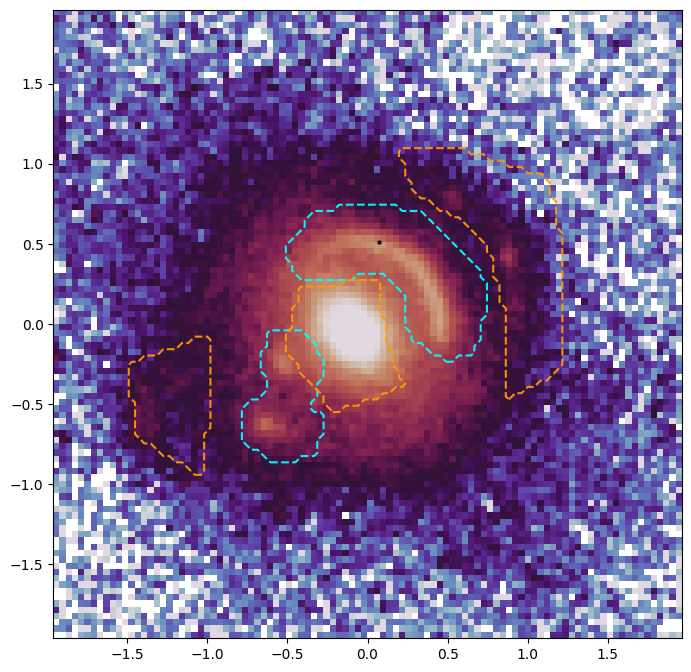

science   : /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_lens_cutout_100x100.fits
source1   : /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_science_100x100_mask_inner.fits
source2   : /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f475w_science_100x100_mask outer.fits
psf       : /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_psf_model_svi.fits
background: /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_background_box_50x50.fits
conjugate : /mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_lens_cutout_100x100_conjugate_points.json
rms       : 0.004453595749110992
mean bg   : 0.00036789767284581103
conj_points_1 [arcsec]: [[0.069335   0.51450727]]


In [2]:
show_plot = True
PREPROCESSED_DIR = NOTEBOOK_DIR / 'preprocessed' / 'prep_20260419_bgbox_psfsvi_v2_flat'
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / 'teapot_singleband_jackpot_epl_v1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREPROCESS_META = json.loads((PREPROCESSED_DIR / 'preprocessing_metadata.json').read_text())
science_path = PREPROCESSED_DIR / 'f814w_lens_cutout_100x100.fits'
mask_1_path = PREPROCESSED_DIR / 'f814w_science_100x100_mask_inner.fits'
mask_2_path = PREPROCESSED_DIR / 'f475w_science_100x100_mask outer.fits'
psf_path = PREPROCESSED_DIR / 'f814w_psf_model_svi.fits'
background_box_path = PREPROCESSED_DIR / 'f814w_background_box_50x50.fits'
conjugate_json_path = PREPROCESSED_DIR / 'f814w_lens_cutout_100x100_conjugate_points.json'
conjugate_payload = json.loads(conjugate_json_path.read_text())

exposure_time = float(PREPROCESS_META['cutouts']['f814w']['exptime_sec'])
rms = float(PREPROCESS_META['cutouts']['f814w']['background_sigma_scalar'])
theta_high = 0.3
theta_low = 0.0

with fits.open(science_path, memmap=True) as hdul_data:
    science_header = hdul_data[0].header
    data_np = np.asarray(hdul_data[0].data, dtype=np.float64)

if 'PIXSCALE' in science_header:
    pix_scale = float(science_header['PIXSCALE'])
elif 'D001SCAL' in science_header:
    pix_scale = float(science_header['D001SCAL'])
else:
    cd11 = science_header.get('CD1_1')
    cd21 = science_header.get('CD2_1')
    if cd11 is None or cd21 is None:
        raise KeyError('Cannot determine pixel scale from science header.')
    pix_scale = float(np.hypot(cd11, cd21) * 3600.0)
with fits.open(mask_1_path, memmap=True) as hdul_mask_1:
    mask_1_np = np.asarray(hdul_mask_1[0].data, dtype=bool)
with fits.open(mask_2_path, memmap=True) as hdul_mask_2:
    mask_2_np = np.asarray(hdul_mask_2[0].data, dtype=bool)
with fits.open(psf_path, memmap=True) as hdul_psf:
    psf_hst = np.asarray(hdul_psf[0].data, dtype=np.float64)
with fits.open(background_box_path, memmap=True) as hdul_bg:
    background_box = np.asarray(hdul_bg[0].data, dtype=np.float64)

mask_out_np = np.isfinite(data_np)
background_pixels = background_box[np.isfinite(background_box)]
mean = float(np.mean(background_pixels))

psf_hst = np.nan_to_num(psf_hst, nan=0.0)
psf_hst = np.clip(psf_hst, a_min=0.0, a_max=None)
psf_hst /= psf_hst.sum()

data = jnp.array(np.nan_to_num(data_np, nan=0.0), dtype=jnp.float64)
mask_1 = jnp.array(mask_1_np, dtype=bool)
mask_2 = jnp.array(mask_2_np, dtype=bool)
mask_out = jnp.array(mask_out_np, dtype=bool)

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(data_np, pix_scale)
psf = PSF(psf_type='PIXEL', kernel_point_source=psf_hst)
noise = Noise(nx, ny, exposure_time=exposure_time)

conjugate_points_fits = np.array([
    [point['x'], point['y']]
    for point in conjugate_payload['conjugatePointsFitsCoordinates']
], dtype=np.float64)
center_xy = np.array([(nx - 1) / 2.0, (ny - 1) / 2.0], dtype=np.float64)
conj_points_1 = (conjugate_points_fits - center_xy) * pix_scale
conj_points_2 = conj_points_1.copy()

if show_plot:
    positive = data_np[np.isfinite(data_np) & (data_np > 0)]
    vmin = max(float(np.percentile(positive, 5)), 1e-6) if positive.size else 1e-6
    vmax = max(float(np.percentile(positive, 99.5)), vmin * 1.01) if positive.size else 1.0
    plt.figure(figsize=(7, 7))
    plt.imshow(data_np, extent=extent, cmap='twilight', origin='lower', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
    plt.contour(mask_1_np, levels=[0.5], colors='#00ffff', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)
    plt.contour(mask_2_np, levels=[0.5], colors='#ff9900', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)
    if conj_points_1.size > 0:
        plt.plot(conj_points_1[:, 0], conj_points_1[:, 1], 'o', color='black', markersize=2)
    plt.tight_layout()
    plt.show()

print('science   :', science_path)
print('source1   :', mask_1_path)
print('source2   :', mask_2_path)
print('psf       :', psf_path)
print('background:', background_box_path)
print('conjugate :', conjugate_json_path)
print('rms       :', rms)
print('mean bg   :', mean)
print('conj_points_1 [arcsec]:', conj_points_1)


In [3]:
mass_model = MPMassModel(
    [
        MassModel(['EPL', 'SHEAR']),
        MassModel(['SIE']),
    ],
)

N_gauss_light = 15
N_gauss_source1 = 4
N_gauss_source2 = 4
ss_factor = 1

light_model = MPLightModel(
    [
        LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
        LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
        LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
    ]
)

sigma_lims_lens = [0.001, 3.0]
sigma_lims_source1 = [0.001, 0.2]
sigma_lims_source2 = [0.001, 0.2]
source_grid_scale = [1, 1, 1]

lens_image = MPLensImage(
    pixel_grid,
    psf,
    noise_class=noise,
    light_model_class=light_model,
    mass_model_class=mass_model,
    conjugate_points=[conj_points_1, conj_points_2],
    source_arc_masks=[None, None, None],
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)


In [4]:
npix = int(mask_out.sum())

def model(data, fit_cosmology=False, parametric=True, svi=True):
    eta = numpyro.sample('eta', dist.Uniform(1.0, 1.5))
    lens_light = multi_gauss_light('Lens light', 'lens', N_gauss_light, sigma_lims_lens, center_low=-0.2, center_high=0.2, e_low=-0.2, e_high=0.2)
    if parametric:
        s1_light = multi_gauss_light('Source light1', 'source1', N_gauss_source1, sigma_lims_source1)
        s2_light = multi_gauss_light('Source light2', 'source2', N_gauss_source2, sigma_lims_source2)
    light_params = [lens_light, s1_light, s2_light]

    EPL_w_shear_params = EPL_w_shear('Lens mass', 'halo', theta_low=0.01, theta_high=2.03)

    conj_points_at_s1 = lens_image.trace_conjugate_points(eta_flat=eta, kwargs_mass=[EPL_w_shear_params], N=1)
    conj_mean_at_s1 = conj_points_at_s1.mean(axis=0)
    mass_params_SIE_s1 = SIE('s1 mass model', 'SIE_s1', origin=conj_mean_at_s1, theta_low=0.05, theta_high=theta_high)

    kwargs_mass_for_s2 = [EPL_w_shear_params, mass_params_SIE_s1]
    if svi:
        conj_distance_1 = reduced_distance_matrix(conj_points_at_s1)
        nc1 = conj_distance_1.shape[0]
        if nc1 > 0:
            with numpyro.plate(f'Conjugate points 1 - [{nc1}]', nc1):
                numpyro.sample('conjugate_points1', dist.Exponential(1000), obs=conj_distance_1)

        conj_points_at_s2 = lens_image.trace_conjugate_points(eta_flat=eta, kwargs_mass=kwargs_mass_for_s2, N=2)
        conj_distance_2 = reduced_distance_matrix(conj_points_at_s2)
        nc2 = conj_distance_2.shape[0]
        if nc2 > 0:
            with numpyro.plate(f'Conjugate points 2 - [{nc2}]', nc2):
                numpyro.sample('conjugate_points2', dist.Exponential(1000), obs=conj_distance_2)

    model_image = lens_image.model(eta_flat=eta, kwargs_mass=kwargs_mass_for_s2, kwargs_light=light_params)

    background_rms_model = numpyro.sample('RMS', dist.LogUniform(rms * 0.8, rms * 1.2))
    model_var = lens_image.Noise.C_D_model(model_image, background_rms=background_rms_model)
    model_std = jnp.sqrt(model_var)

    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]

    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])


def params2kwargs(params, fixed_params={}):
    params_full = params | fixed_params
    kwargs_lens_light = params2kwargs_multi_gauss_light(params_full, 'lens', sigma_lims_lens)
    kwargs_lens_epl_shear = params2kwargs_EPL_w_shear(params, 'halo')
    kwargs_SIE_s1 = params2kwargs_SIE(params_full, 'SIE_s1')
    kwargs_lens = [kwargs_lens_epl_shear, kwargs_SIE_s1]

    s1 = params2kwargs_multi_gauss_light(params_full, 'source1', sigma_lims_source1)
    s2 = params2kwargs_multi_gauss_light(params_full, 'source2', sigma_lims_source2)
    kwargs_light = [kwargs_lens_light, s1, s2]
    return {'eta_flat': params['eta'], 'kwargs_mass': kwargs_lens, 'kwargs_light': kwargs_light}


Running for 10,000 iterations: 100%|██████| 10000/10000 [10:32<00:00, 15.81it/s]


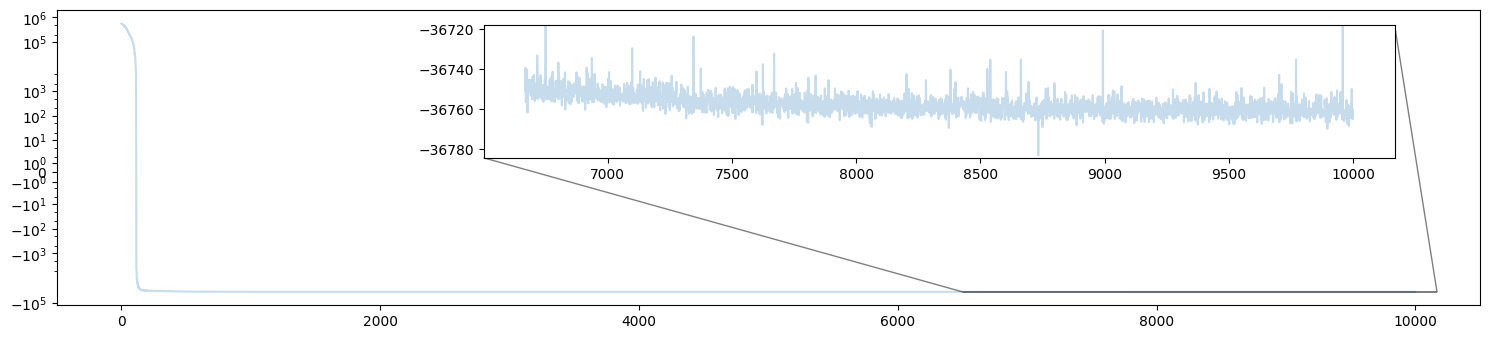

final parametric loss: -36762.24727562814
eta: 1.295632044190397
RMS: 0.005037588753137998


In [5]:
max_iterations = 10000
num_chains = 1

init_fun = infer.init_to_median(num_samples=25)
guide = autoguide.AutoLowRankMultivariateNormal(model, init_loc_fn=init_fun)
scheduler = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.Trace_ELBO(num_particles=10)
rng_key = jax.random.PRNGKey(100)
rng_key, rng_key_ = jax.random.split(rng_key)
svi = SVI_vec(model, guide, optim, loss)
multi_svi_results = svi.run(rng_key, num_chains, max_iterations, data, stable_update=True)
multi_svi_median = guide.median(multi_svi_results.params)

fig, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])
for losses in multi_svi_results.losses:
    plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'parametric_svi_loss.png', dpi=150)
plt.show()

print('final parametric loss:', float(multi_svi_results.losses[0, -1]))
print('eta:', float(np.asarray(multi_svi_median['eta'])[0]))
print('RMS:', float(np.asarray(multi_svi_median['RMS'])[0]))


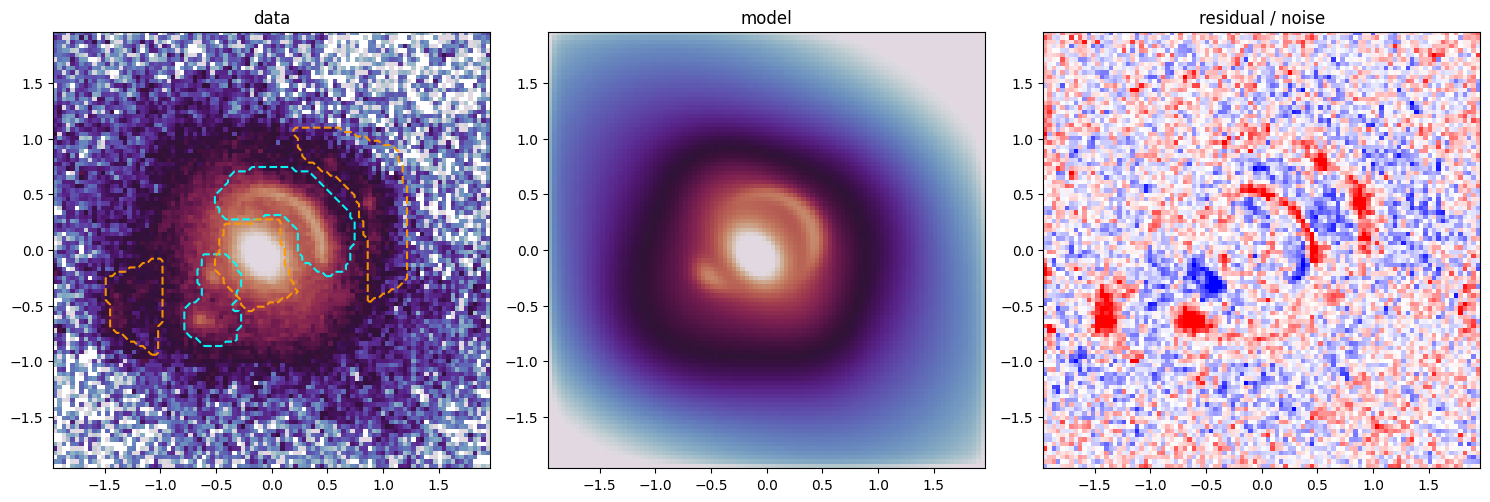

best_i: 0


In [6]:
multi_svi_median_herc = median_params2kwargs(params2kwargs, multi_svi_median, jnp.arange(num_chains))
best_i = int(multi_svi_results.losses[:, -1000:].mean(axis=1).argmin())

for i in range(num_chains):
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    positive = np.asarray(data)[np.asarray(data) > 0]
    vmin = max(float(np.percentile(positive, 5)), 1e-6) if positive.size else 1e-6
    vmax = max(float(np.percentile(positive, 99.5)), vmin * 1.01) if positive.size else 1.0
    plt.imshow(np.asarray(data), origin='lower', extent=extent, cmap='twilight', norm=colors.LogNorm(vmax=vmax, vmin=vmin))
    plt.contour(np.asarray(mask_1, dtype=float), levels=[0.5], colors='#00ffff', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)
    plt.contour(np.asarray(mask_2, dtype=float), levels=[0.5], colors='#ff9900', alpha=0.95, linestyles='dashed', origin='lower', extent=extent)
    plt.title('data')

    plt.subplot(132)
    model_image = lens_image.model(**get_value_from_index(multi_svi_median_herc, i))
    model_positive = np.asarray(model_image)[np.asarray(model_image) > 0]
    model_vmin = max(float(np.percentile(model_positive, 5)), 1e-6) if model_positive.size else 1e-6
    model_vmax = max(float(np.percentile(model_positive, 99.5)), model_vmin * 1.01) if model_positive.size else 1.0
    plt.imshow(np.asarray(model_image), origin='lower', extent=extent, cmap='twilight', norm=colors.LogNorm(vmax=model_vmax, vmin=model_vmin))
    plt.title('model')

    plt.subplot(133)
    bg_rms = multi_svi_median['RMS'][i]
    model_std = jnp.sqrt(lens_image.Noise.C_D_model(model_image, background_rms=bg_rms))
    plt.imshow((data - model_image) / model_std, origin='lower', vmax=3, vmin=-3, extent=extent, cmap='bwr')
    plt.title('residual / noise')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'parametric_model_chain_{i}.png', dpi=150)
    plt.show()

print('best_i:', best_i)


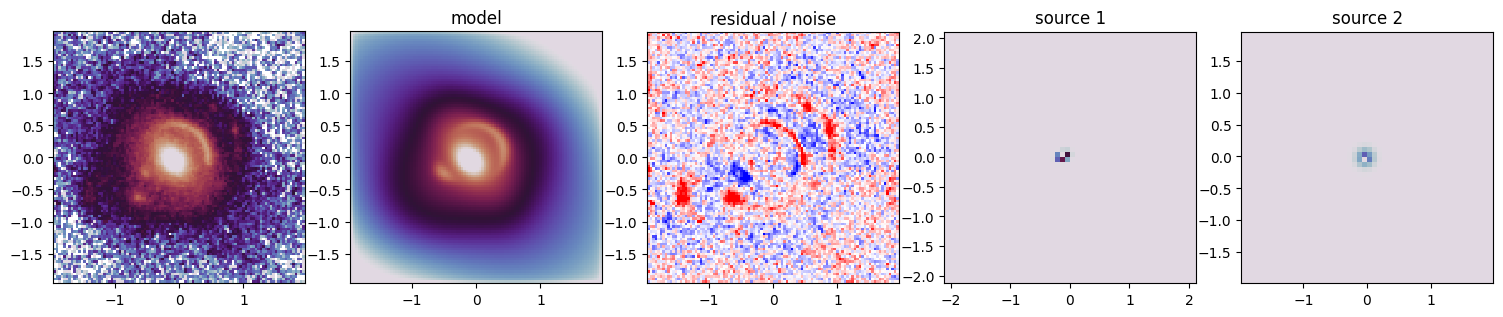

{'science_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_lens_cutout_100x100.fits',
 'mask_1_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_science_100x100_mask_inner.fits',
 'mask_2_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f475w_science_100x100_mask outer.fits',
 'psf_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_psf_model_svi.fits',
 'background_box_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_background_box_50x50.fits',
 'conjugate_json_path': '/mnt/d/lensing/Herculens/DSPL_LensModel/preprocessed/prep_20260419_bgbox_psfsvi_v2_flat/f814w_lens_cutout_100x100_conjugate_points.json',
 'pix_scale': 0.03961999999999999,
 'exposure_time': 2300.0,
 'rms': 0.004453595749110992,
 'num_chains': 1,
 'max_iterations': 1000

summary: /mnt/d/lensing/Herculens/DSPL_LensModel/outputs/teapot_singleband_jackpot_epl_v1/summary_parametric.json


In [7]:
pixel_grid_shape = 50

def get_image(idx, N, pixel_grid_shape):
    i1, extent_src = pixelize_plane(
        lens_image,
        get_value_from_index(multi_svi_median_herc, idx),
        pixel_grid_shape,
        source_grid_scale=source_grid_scale[N],
        N=N,
    )
    return i1, extent_src

for i in range(num_chains):
    plt.figure(figsize=(15, 5))
    plt.subplot(151)
    positive = np.asarray(data)[np.asarray(data) > 0]
    vmin = max(float(np.percentile(positive, 5)), 1e-6) if positive.size else 1e-6
    vmax = max(float(np.percentile(positive, 99.5)), vmin * 1.01) if positive.size else 1.0
    plt.imshow(np.asarray(data), origin='lower', extent=extent, cmap='twilight', norm=colors.LogNorm(vmax=vmax, vmin=vmin))
    plt.title('data')

    plt.subplot(152)
    model_image = lens_image.model(**get_value_from_index(multi_svi_median_herc, i))
    model_positive = np.asarray(model_image)[np.asarray(model_image) > 0]
    model_vmin = max(float(np.percentile(model_positive, 5)), 1e-6) if model_positive.size else 1e-6
    model_vmax = max(float(np.percentile(model_positive, 99.5)), model_vmin * 1.01) if model_positive.size else 1.0
    plt.imshow(np.asarray(model_image), origin='lower', extent=extent, cmap='twilight', norm=colors.LogNorm(vmax=model_vmax, vmin=model_vmin))
    plt.title('model')

    plt.subplot(153)
    bg_rms = multi_svi_median['RMS'][i]
    model_std = jnp.sqrt(lens_image.Noise.C_D_model(model_image, background_rms=bg_rms))
    plt.imshow(np.asarray((data - model_image) / model_std), origin='lower', vmax=3, vmin=-3, extent=extent, cmap='bwr')
    plt.title('residual / noise')

    orig_source_1, extent_s1 = get_image(i, 1, pixel_grid_shape)
    orig_source_2, extent_s2 = get_image(i, 2, pixel_grid_shape)
    plt.subplot(154)
    plt.imshow(np.asarray(orig_source_1), origin='lower', extent=extent_s1, cmap='twilight')
    plt.title('source 1')
    plt.subplot(155)
    plt.imshow(np.asarray(orig_source_2), origin='lower', extent=extent_s2, cmap='twilight')
    plt.title('source 2')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'parametric_source_planes_chain_{i}.png', dpi=150)
    plt.show()

summary = {
    'science_path': str(science_path),
    'mask_1_path': str(mask_1_path),
    'mask_2_path': str(mask_2_path),
    'psf_path': str(psf_path),
    'background_box_path': str(background_box_path),
    'conjugate_json_path': str(conjugate_json_path),
    'pix_scale': pix_scale,
    'exposure_time': exposure_time,
    'rms': rms,
    'num_chains': num_chains,
    'max_iterations': max_iterations,
    'best_i': best_i,
    'final_parametric_loss': float(multi_svi_results.losses[best_i, -1]),
    'eta': float(np.asarray(multi_svi_median['eta'])[best_i]),
    'RMS_fit': float(np.asarray(multi_svi_median['RMS'])[best_i]),
}
summary_path = OUTPUT_DIR / 'summary_parametric.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
display(summary)
print('summary:', summary_path)
